<a href="https://colab.research.google.com/github/lakmg2007/SCALAR_LEARNINGS/blob/main/CO2_Emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO₂ Emission Prediction

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
DATA_PATH = "/content/CO2_Emissions.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst five rows:")
display(df.head())

Shape of dataset: (7385, 12)

Column names:
['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

Data types:


,0
Make,object
Model,object
Vehicle Class,object
Engine Size(L),float64
Cylinders,int64
Transmission,object
Fuel Type,object
Fuel Consumption City (L/100 km),float64
Fuel Consumption Hwy (L/100 km),float64
Fuel Consumption Comb (L/100 km),float64



First five rows:


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())

Missing values:


,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0



Duplicate rows: 1103

Summary statistics:


,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [6]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("After removing duplicates:", df_clean.shape)

Original shape: (7385, 12)
After removing duplicates: (6282, 12)


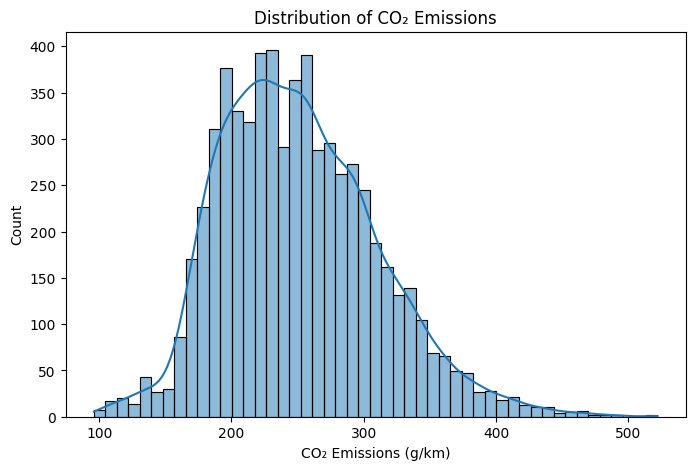

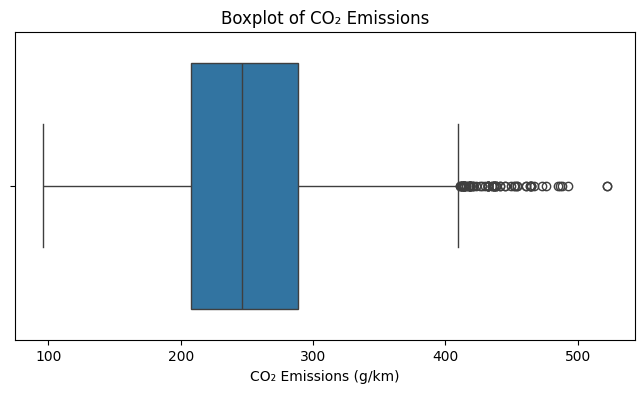

In [7]:
target = "CO2 Emissions(g/km)"

plt.figure(figsize=(8,5))
sns.histplot(df_clean[target], kde=True)
plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean[target])
plt.title("Boxplot of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.show()

,CO2 Emissions(g/km)
CO2 Emissions(g/km),1.000000
Fuel Consumption City (L/100 km),0.918756
Fuel Consumption Comb (L/100 km),0.916840
Fuel Consumption Hwy (L/100 km),0.883424
Engine Size(L),0.854802
Cylinders,0.834687
Fuel Consumption Comb (mpg),-0.906783


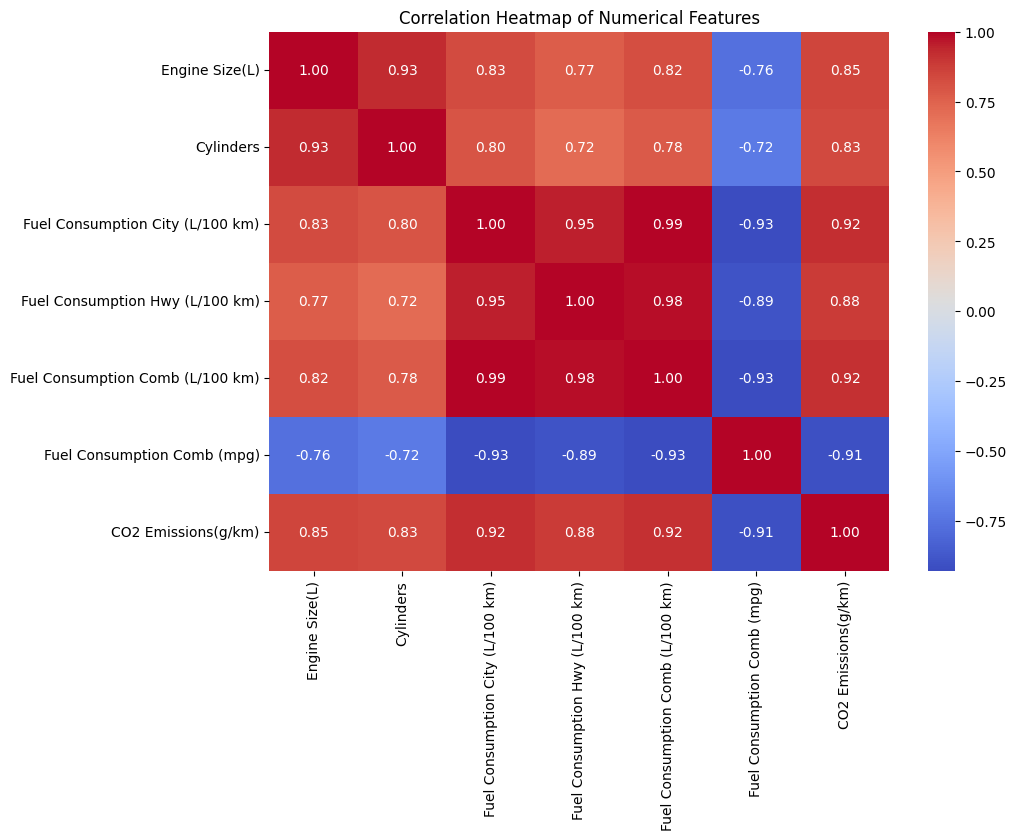

In [8]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

corr_with_target = df_clean[numeric_cols].corr()[target].sort_values(ascending=False)
display(corr_with_target)

plt.figure(figsize=(10,7))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Correlation Interpretation

Fuel consumption variables are expected to show the strongest relationship with CO₂ emissions.  
Engine size and number of cylinders are also expected to be positively related to emissions.  
`Fuel Consumption Comb (mpg)` usually has a negative relationship because higher mpg means better fuel efficiency and lower emissions.

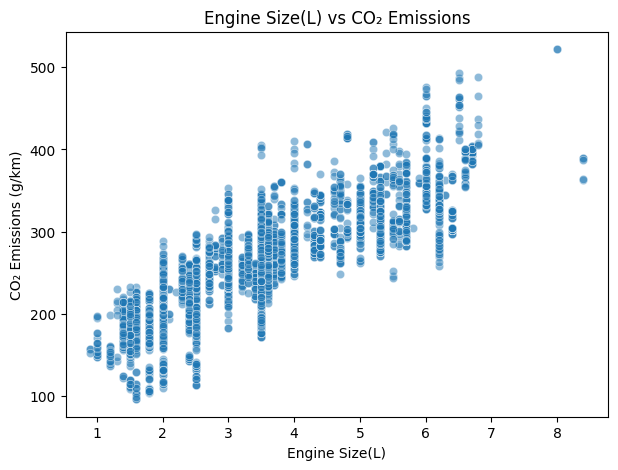

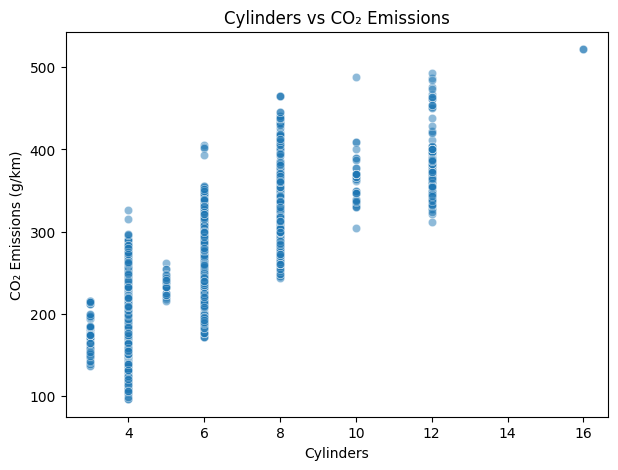

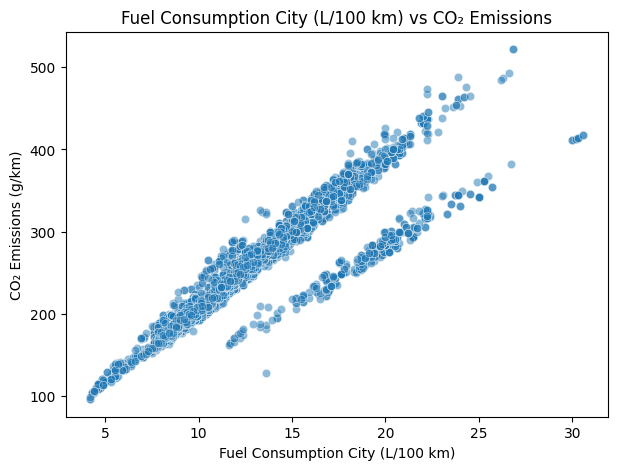

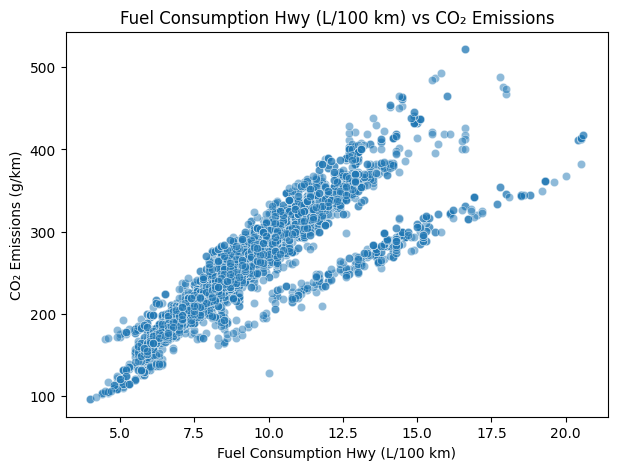

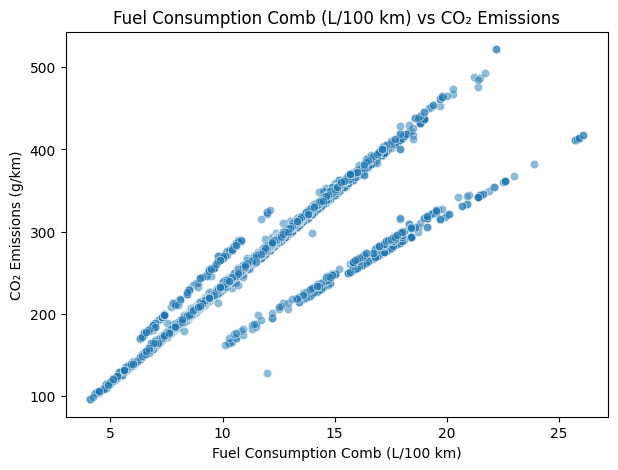

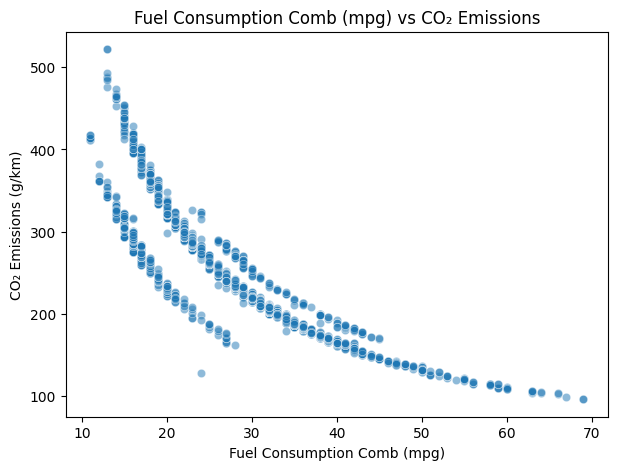

In [9]:
important_num_cols = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

for col in important_num_cols:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_clean, x=col, y=target, alpha=0.5)
    plt.title(f"{col} vs CO₂ Emissions")
    plt.xlabel(col)
    plt.ylabel("CO₂ Emissions (g/km)")
    plt.show()

### Numerical Pattern Summary

From the scatter plots:
- CO₂ emissions increase as fuel consumption in L/100 km increases.
- Larger engine size usually leads to higher emissions.
- More cylinders generally indicate higher emissions.
- Higher mpg is linked with lower emissions.

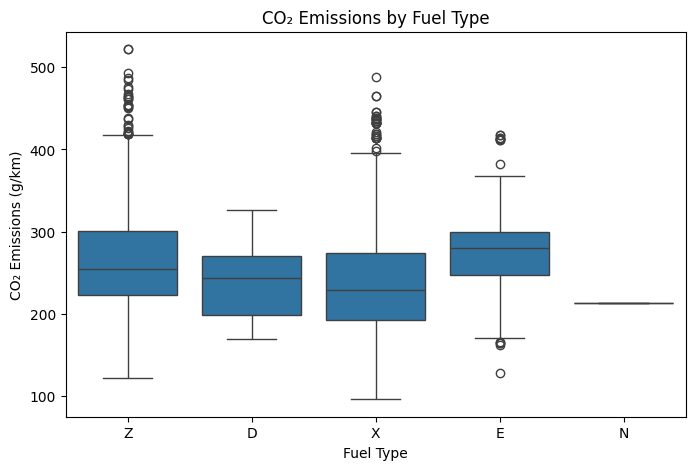

,count,mean,median,min,max
Fuel Type,,,,,
E,330,276.048485,280.0,128,418
Z,2765,265.731284,254.0,122,522
X,3039,235.977953,229.0,96,488
D,147,235.238095,243.0,169,326
N,1,213.000000,213.0,213,213


In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="Fuel Type", y=target)
plt.title("CO₂ Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("CO₂ Emissions (g/km)")
plt.show()

fuel_summary = df_clean.groupby("Fuel Type")[target].agg(["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)
display(fuel_summary)

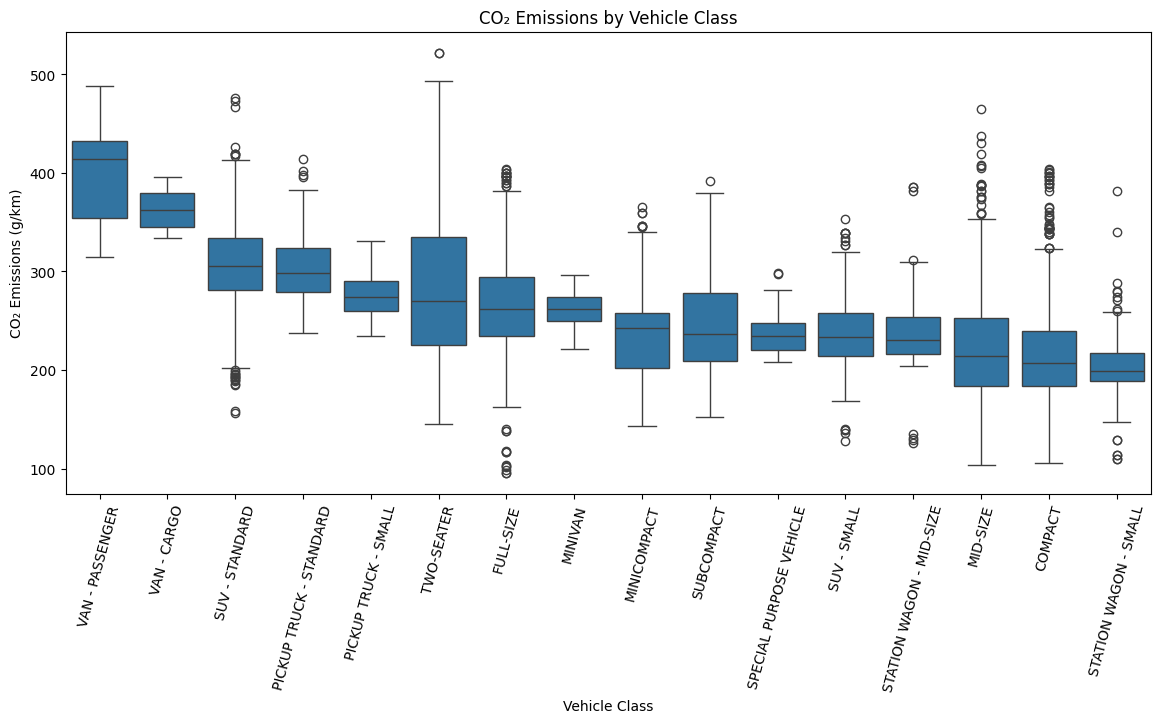

,count,mean,median
Vehicle Class,,,
VAN - PASSENGER,66,397.212121,414.0
VAN - CARGO,22,361.500000,362.0
SUV - STANDARD,613,306.730832,306.0
PICKUP TRUCK - STANDARD,475,301.610526,298.0
TWO-SEATER,381,282.086614,270.0
PICKUP TRUCK - SMALL,133,277.022556,274.0
FULL-SIZE,508,264.407480,262.0
MINIVAN,61,261.114754,262.0
SUBCOMPACT,533,244.568480,237.0


In [11]:
plt.figure(figsize=(14,6))
order = df_clean.groupby("Vehicle Class")[target].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="Vehicle Class", y=target, order=order)
plt.title("CO₂ Emissions by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("CO₂ Emissions (g/km)")
plt.xticks(rotation=75)
plt.show()

vehicle_class_summary = df_clean.groupby("Vehicle Class")[target].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
display(vehicle_class_summary.head(10))

In [12]:
Q1 = df_clean[target].quantile(0.25)
Q3 = df_clean[target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean[target] < lower_bound) | (df_clean[target] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of CO₂ emission outliers:", outliers.shape[0])

display(outliers.sort_values(target, ascending=False).head(10))

Lower bound: 86.5
Upper bound: 410.5
Number of CO₂ emission outliers: 74


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
5575,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
4509,BUGATTI,CHIRON,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
6046,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,26.6,15.8,21.7,13,493
349,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,A5,X,23.9,17.8,21.2,13,488
6045,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.3,15.6,21.5,13,487
7058,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.2,15.5,21.4,13,485
2971,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,AS7,Z,24.3,17.9,21.4,13,476
5126,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,A7,Z,22.2,18.0,20.3,14,473
4049,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,AS7,Z,22.2,18.0,20.3,14,467
2434,CHEVROLET,EXPRESS 3500 PASSENGER,VAN - PASSENGER,6.0,8,A6,X,23.0,16.0,19.8,14,465


### Outlier Decision

The high-emission records are not automatically removed because they may represent genuine vehicles such as large SUVs, vans, and high-performance models.  
For a policy and design case study, these vehicles are important because they show where emission reduction efforts may matter most.

In [13]:
vif_features = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

X_vif = df_clean[vif_features].copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

display(vif_data.sort_values("VIF", ascending=False))

,Feature,VIF
4,Fuel Consumption Comb (L/100 km),75440.706943
2,Fuel Consumption City (L/100 km),30259.576199
3,Fuel Consumption Hwy (L/100 km),10501.080825
1,Cylinders,78.945465
0,Engine Size(L),55.149606
5,Fuel Consumption Comb (mpg),6.885935


### Multicollinearity Handling

To keep the model interpretable, redundant fuel consumption columns are removed.  
We keep **Fuel Consumption Comb (L/100 km)** because it directly represents combined real-world consumption and is easy to explain.

Dropped columns:
- Fuel Consumption City (L/100 km)
- Fuel Consumption Hwy (L/100 km)
- Fuel Consumption Comb (mpg)

This simplifies the model and reduces multicollinearity.

In [14]:
target = "CO2 Emissions(g/km)"

# Model column is high-cardinality and less useful for a simple interpretable policy model.
# Redundant fuel-consumption columns are dropped to reduce multicollinearity.
drop_columns = [
    target,
    "Model",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

X = df_clean.drop(columns=drop_columns)
y = df_clean[target]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']
Categorical features: ['Make', 'Vehicle Class', 'Transmission', 'Fuel Type']


In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance on Test Data")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Performance on Test Data
MAE : 3.34
RMSE: 5.91
R²  : 0.9903


In [18]:
cv_scores = cross_val_score(
    ridge_model, X, y, cv=5, scoring="r2"
)

print("Cross-validation R² scores:", np.round(cv_scores, 4))
print("Mean CV R²:", round(cv_scores.mean(), 4))

Cross-validation R² scores: [0.9819 0.9866 0.992  0.9952 0.9961]
Mean CV R²: 0.9903


### Evaluation Interpretation

- **MAE** shows the average prediction error in g/km.
- **RMSE** gives stronger penalty to large errors.
- **R²** explains how much variation in CO₂ emissions is captured by the model.

A high R² and low error values indicate that vehicle characteristics and fuel consumption are strong predictors of CO₂ emissions.

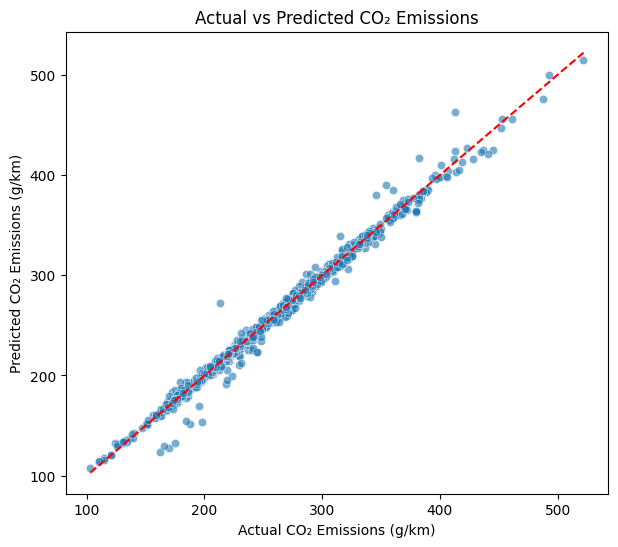

In [19]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Actual vs Predicted CO₂ Emissions")
plt.xlabel("Actual CO₂ Emissions (g/km)")
plt.ylabel("Predicted CO₂ Emissions (g/km)")
plt.show()

In [20]:
results = X_test.copy()
results["Actual_CO2"] = y_test
results["Predicted_CO2"] = y_pred
results["Residual"] = results["Actual_CO2"] - results["Predicted_CO2"]
results["Absolute_Error"] = results["Residual"].abs()

display(results.sort_values("Absolute_Error", ascending=False).head(15))

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),Actual_CO2,Predicted_CO2,Residual,Absolute_Error
2439,CHEVROLET,MID-SIZE,3.6,6,AS6,N,12.7,213,272.331485,-59.331485,59.331485
228,CHEVROLET,VAN - PASSENGER,6.0,8,A6,E,25.8,413,462.652033,-49.652033,49.652033
2990,MERCEDES-BENZ,COMPACT,2.0,4,AS7,E,11.6,198,153.712935,44.287065,44.287065
2612,FORD,COMPACT,2.0,4,AM6,E,10.3,170,127.589013,42.410987,42.410987
2614,FORD,COMPACT,2.0,4,AS6,E,10.5,175,133.130489,41.869511,41.869511
408,FORD,COMPACT,2.0,4,A6,E,10.1,162,123.215487,38.784513,38.784513
3694,FORD,COMPACT,2.0,4,M5,E,11.4,188,151.598322,36.401678,36.401678
1488,FORD,COMPACT,2.0,4,AM6,E,10.4,166,129.778859,36.221141,36.221141
476,GMC,SUV - STANDARD,6.2,8,A6,E,22.1,354,389.809716,-35.809716,35.809716
351,FORD,VAN - PASSENGER,5.4,8,A4,E,23.9,382,416.984054,-34.984054,34.984054


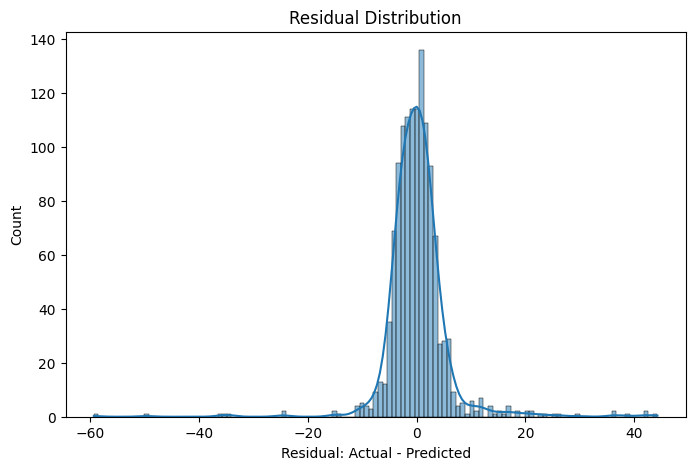

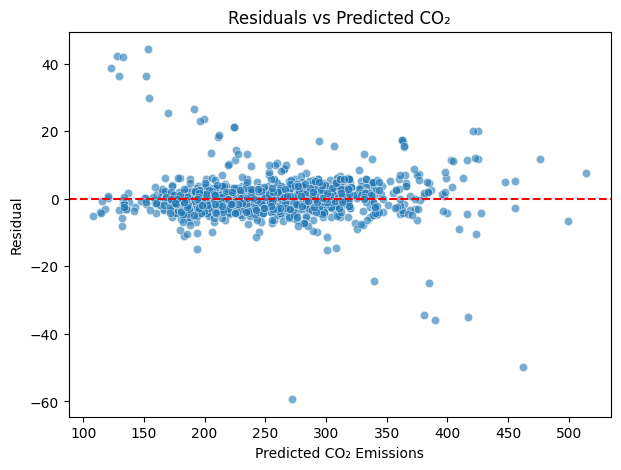

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(results["Residual"], kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual: Actual - Predicted")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(x=results["Predicted_CO2"], y=results["Residual"], alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted CO₂")
plt.xlabel("Predicted CO₂ Emissions")
plt.ylabel("Residual")
plt.show()

### Residual Interpretation

The highest-error vehicles should be reviewed because they may belong to rare vehicle classes, unusual fuel types, or extreme engine/fuel-consumption combinations.  
This helps identify where the model is weaker and where more detailed vehicle information may be needed.

,Feature,Importance
6,Fuel Consumption Comb (L/100 km),2.307922
5,Fuel Type,0.364982
0,Make,0.001258
3,Cylinders,0.000937
1,Vehicle Class,0.000863
4,Transmission,0.000627
2,Engine Size(L),0.000083


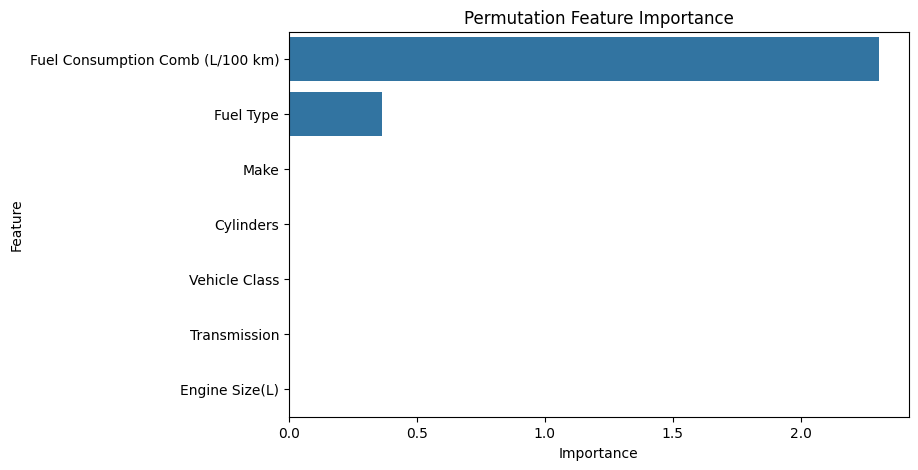

In [22]:
perm_importance = permutation_importance(
    ridge_model, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Permutation Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 17. Case Study Questions
### 1. Dataset Familiarization
The dataset captures vehicle manufacturer, model, vehicle class, engine size, cylinders, transmission type, fuel type, fuel consumption values, and CO₂ emissions. These variables are relevant because vehicle design and fuel efficiency directly affect emissions.

### 2. Data Quality and Preprocessing
The dataset was checked for missing values, duplicates, and data types. Duplicate rows were removed. Numerical and categorical variables were separated. Categorical variables were encoded using one-hot encoding, while numerical variables were scaled.

### 3. Relationship Between Features and CO₂ Emissions
Fuel consumption, engine size, and cylinders show strong influence on CO₂ emissions. Higher fuel consumption, larger engine size, and more cylinders generally lead to higher emissions.

### 4. Visual Summary of Numerical Variables
Scatter plots show a clear upward pattern between fuel consumption in L/100 km and CO₂ emissions. Engine size and cylinders also show positive relationships with emissions.

### 5. Comparison Across Categories
Vehicle class and fuel type show clear emission differences. Larger vehicles such as vans, SUVs, and pickup trucks tend to have higher emissions. Fuel-type differences are visible, but they should be interpreted along with vehicle type and engine size.

### 6. Unusual Vehicles
Some vehicles produce unusually high or low emissions compared with others. These are likely due to special vehicle classes, high-performance engines, or rare fuel/engine combinations. They were retained because they are meaningful for policy analysis.

### 7. Dataset Preparation for Modeling
The model used selected numerical and categorical features. Redundant fuel consumption columns were removed to reduce multicollinearity. Categorical variables were one-hot encoded, and numerical variables were scaled inside a pipeline.

### 8. Model Development
Ridge Regression was selected as a simple and interpretable regression model. It estimates CO₂ emissions using engine size, cylinders, combined fuel consumption, vehicle class, transmission, fuel type, and make.

### 9. Model Performance
The model was evaluated using MAE, RMSE, R², and cross-validation R². These metrics show both average error and overall explanatory power. A strong R² indicates that the selected features explain most of the variation in emissions.

### 10. Final Insights and Recommendations
The strongest drivers of CO₂ emissions are fuel consumption, engine capacity, cylinders, and vehicle class. Emission reduction efforts should focus on improving fuel efficiency, encouraging smaller and more efficient engine designs, and reducing the share of high-emission vehicle classes in the fleet.

## 18. Business Recommendations

1. **Improve fuel efficiency standards:** Since fuel consumption is the strongest driver of CO₂ emissions, stricter efficiency targets can directly reduce emissions.
2. **Encourage smaller engine designs:** Larger engines and more cylinders are linked with higher emissions.
3. **Focus on high-emission vehicle classes:** Vans, standard SUVs, and pickup trucks should be priority categories for emission-reduction policies.
4. **Use model-based monitoring:** The regression model can help estimate expected emissions and identify vehicles that deviate unusually from expected values.
5. **Support cleaner technology adoption:** Hybrid, electric, and improved combustion technologies can help reduce emissions across vehicle categories.